# ANALISIS KOMPARASI ALGORITMA MACHINE LEARNING PADA KLASIFIKASI KELAYAKAN PINJAMAN NASABAH

Notebook ini membandingkan empat algoritma klasifikasi, yaitu **Random Forest**, **LightGBM**, **CatBoost**, dan **Logistic Regression** pada dataset prediksi persetujuan pinjaman. Fokus utama eksperimen tidak hanya pada akurasi, tetapi juga pada **pencegahan data leakage**, **pengendalian overfitting**, dan **kekuatan interpretasi hasil**.


## Profil Dataset

- **Sumber dataset**: Kaggle, dataset *Loan Approval Prediction Dataset*
- **File yang digunakan**: `loan_approval_dataset.csv`
- **Jumlah observasi**: 4.269 baris
- **Jumlah fitur awal**: 13 kolom
- **Jenis masalah**: klasifikasi biner
- **Label target**: `loan_status`
- **Kelas target**: `Disetujui` dan `Ditolak`

Dataset ini berisi informasi tanggungan, pendidikan, status pekerjaan mandiri, pendapatan tahunan, jumlah pinjaman, tenor pinjaman, skor CIBIL, dan beberapa komponen aset. Berdasarkan fitur-fitur tersebut, model akan memprediksi apakah pengajuan pinjaman layak disetujui atau tidak.


## Kamus Dataset

| Nama Kolom | Jenis Data | Keterangan |
|---|---|---|
| `loan_id` | Numerik | Identitas unik pinjaman |
| `no_of_dependents` | Numerik | Jumlah tanggungan peminjam |
| `education` | Kategorikal | Tingkat pendidikan peminjam |
| `self_employed` | Kategorikal | Status bekerja mandiri |
| `income_annum` | Numerik | Pendapatan tahunan |
| `loan_amount` | Numerik | Nilai pinjaman yang diajukan |
| `loan_term` | Numerik | Jangka waktu pinjaman |
| `cibil_score` | Numerik | Skor kelayakan kredit |
| `residential_assets_value` | Numerik | Nilai aset residensial |
| `commercial_assets_value` | Numerik | Nilai aset komersial |
| `luxury_assets_value` | Numerik | Nilai aset mewah |
| `bank_asset_value` | Numerik | Nilai aset di bank |
| `loan_status` | Kategorikal | Status persetujuan pinjaman |


## Import Library


In [1]:
from __future__ import annotations

import os
import warnings
from pathlib import Path

os.environ["MPLCONFIGDIR"] = str((Path.cwd() / ".matplotlib").resolve())
os.environ["LOKY_MAX_CPU_COUNT"] = "1"
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import Markdown, display
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
)
from sklearn.model_selection import (
    ParameterGrid,
    StratifiedKFold,
    cross_val_score,
    train_test_split,
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="Set2")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda nilai: f"{nilai:,.4f}")

BENIH_ACAK = 42
lokasi_dataset = Path.cwd() / "loan_approval_dataset.csv"

if not lokasi_dataset.exists():
    raise FileNotFoundError(f"Dataset tidak ditemukan: {lokasi_dataset}")

print(f"Dataset aktif: {lokasi_dataset}")


Dataset aktif: /Users/danuste/Desktop/skripsi-2/loan_approval_dataset.csv


## EDA


In [2]:
kolom_aset = [
    "residential_assets_value",
    "commercial_assets_value",
    "luxury_assets_value",
    "bank_asset_value",
]

peta_status_tampilan = {"Rejected": "Ditolak", "Approved": "Disetujui"}
peta_pendidikan_tampilan = {"Graduate": "Lulusan", "Not Graduate": "Belum Lulus"}
peta_status_mandiri_tampilan = {"Yes": "Ya", "No": "Tidak"}
peta_nama_kolom_tampilan = {
    "loan_id": "ID Pinjaman",
    "no_of_dependents": "Jumlah Tanggungan",
    "education": "Pendidikan",
    "self_employed": "Pekerjaan Mandiri",
    "income_annum": "Pendapatan Tahunan",
    "loan_amount": "Jumlah Pinjaman",
    "loan_term": "Jangka Waktu Pinjaman",
    "cibil_score": "Skor CIBIL",
    "residential_assets_value": "Nilai Aset Residensial",
    "commercial_assets_value": "Nilai Aset Komersial",
    "luxury_assets_value": "Nilai Aset Mewah",
    "bank_asset_value": "Nilai Aset Bank",
    "loan_status": "Status Pinjaman",
    "target_eda": "Target EDA",
    "total_assets_value": "Total Nilai Aset",
    "rasio_pinjaman_pendapatan": "Rasio Pinjaman terhadap Pendapatan",
    "rasio_agunan_pinjaman": "Rasio Agunan terhadap Pinjaman",
    "target_kelayakan": "Target Kelayakan",
}

data_awal = pd.read_csv(lokasi_dataset)
data_awal.columns = [kolom.strip() for kolom in data_awal.columns]

data_eda = data_awal.copy()
for kolom in ["education", "self_employed", "loan_status"]:
    data_eda[kolom] = data_eda[kolom].astype(str).str.strip()

data_eda["target_eda"] = data_eda["loan_status"].map({"Rejected": 0, "Approved": 1})

ringkasan_awal_dataset = pd.DataFrame(
    {
        "komponen": [
            "Jumlah baris",
            "Jumlah kolom awal",
            "Nilai hilang",
            "Data duplikat",
            "Jumlah nilai aset negatif",
        ],
        "nilai": [
            len(data_eda),
            data_eda.shape[1] - 1,
            int(data_eda.drop(columns=["target_eda"]).isna().sum().sum()),
            int(data_eda.drop(columns=["target_eda"]).duplicated().sum()),
            int((data_eda[kolom_aset] < 0).sum().sum()),
        ],
    }
)

data_tampilan_awal = data_eda.drop(columns=["target_eda"]).head().copy()
data_tampilan_awal["education"] = data_tampilan_awal["education"].replace(peta_pendidikan_tampilan)
data_tampilan_awal["self_employed"] = data_tampilan_awal["self_employed"].replace(peta_status_mandiri_tampilan)
data_tampilan_awal["loan_status"] = data_tampilan_awal["loan_status"].replace(peta_status_tampilan)

display(data_tampilan_awal.rename(columns=peta_nama_kolom_tampilan))
display(ringkasan_awal_dataset)


,ID Pinjaman,Jumlah Tanggungan,Pendidikan,Pekerjaan Mandiri,Pendapatan Tahunan,Jumlah Pinjaman,Jangka Waktu Pinjaman,Skor CIBIL,Nilai Aset Residensial,Nilai Aset Komersial,Nilai Aset Mewah,Nilai Aset Bank,Status Pinjaman
0,1,2,Lulusan,Tidak,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Disetujui
1,2,0,Belum Lulus,Ya,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Ditolak
2,3,3,Lulusan,Tidak,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Ditolak
3,4,3,Lulusan,Tidak,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Ditolak
4,5,5,Belum Lulus,Ya,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Ditolak


,komponen,nilai
0,Jumlah baris,4269
1,Jumlah kolom awal,13
2,Nilai hilang,0
3,Data duplikat,0
4,Jumlah nilai aset negatif,28


In [3]:
distribusi_target = (
    data_eda["loan_status"]
    .replace(peta_status_tampilan)
    .value_counts()
    .rename_axis("status_pinjaman")
    .reset_index(name="jumlah")
)
distribusi_target["persentase"] = (distribusi_target["jumlah"] / len(data_eda) * 100).round(2)

ringkasan_numerik = (
    data_eda.drop(columns=["target_eda"])
    .describe()
    .transpose()
    .reset_index()
    .rename(columns={"index": "kolom"})
)
ringkasan_numerik["kolom"] = ringkasan_numerik["kolom"].replace(peta_nama_kolom_tampilan)

ringkasan_numerik_tampilan = ringkasan_numerik[
    ["kolom", "mean", "std", "min", "25%", "50%", "75%", "max"]
].rename(
    columns={
        "kolom": "variabel",
        "mean": "rata_rata",
        "std": "simpangan_baku",
        "min": "minimum",
        "25%": "kuartil_1",
        "50%": "median",
        "75%": "kuartil_3",
        "max": "maksimum",
    }
)

ringkasan_kategorikal = pd.DataFrame(
    {
        "variabel": ["Pendidikan", "Pekerjaan Mandiri", "Status Pinjaman"],
        "jumlah_kategori": [
            data_eda["education"].nunique(),
            data_eda["self_employed"].nunique(),
            data_eda["loan_status"].nunique(),
        ],
        "modus": [
            data_eda["education"].replace(peta_pendidikan_tampilan).mode()[0],
            data_eda["self_employed"].replace(peta_status_mandiri_tampilan).mode()[0],
            data_eda["loan_status"].replace(peta_status_tampilan).mode()[0],
        ],
    }
)

display(distribusi_target)
display(ringkasan_numerik_tampilan)
display(ringkasan_kategorikal)


,status_pinjaman,jumlah,persentase
0,Disetujui,2656,62.2200
1,Ditolak,1613,37.7800


,variabel,rata_rata,simpangan_baku,minimum,kuartil_1,median,kuartil_3,maksimum
0,ID Pinjaman,"2,135.0000","1,232.4985",1.0000,"1,068.0000","2,135.0000","3,202.0000","4,269.0000"
1,Jumlah Tanggungan,2.4987,1.6959,0.0000,1.0000,3.0000,4.0000,5.0000
2,Pendapatan Tahunan,"5,059,123.9166","2,806,839.8318","200,000.0000","2,700,000.0000","5,100,000.0000","7,500,000.0000","9,900,000.0000"
3,Jumlah Pinjaman,"15,133,450.4568","9,043,362.9848","300,000.0000","7,700,000.0000","14,500,000.0000","21,500,000.0000","39,500,000.0000"
4,Jangka Waktu Pinjaman,10.9004,5.7092,2.0000,6.0000,10.0000,16.0000,20.0000
5,Skor CIBIL,599.9361,172.4304,300.0000,453.0000,600.0000,748.0000,900.0000
6,Nilai Aset Residensial,"7,472,616.5378","6,503,636.5877","-100,000.0000","2,200,000.0000","5,600,000.0000","11,300,000.0000","29,100,000.0000"
7,Nilai Aset Komersial,"4,973,155.3057","4,388,966.0896",0.0000,"1,300,000.0000","3,700,000.0000","7,600,000.0000","19,400,000.0000"
8,Nilai Aset Mewah,"15,126,305.9264","9,103,753.6653","300,000.0000","7,500,000.0000","14,600,000.0000","21,700,000.0000","39,200,000.0000"
9,Nilai Aset Bank,"4,976,692.4338","3,250,185.3057",0.0000,"2,300,000.0000","4,600,000.0000","7,100,000.0000","14,700,000.0000"


,variabel,jumlah_kategori,modus
0,Pendidikan,2,Lulusan
1,Pekerjaan Mandiri,2,Ya
2,Status Pinjaman,2,Disetujui


## Visualisasi Data


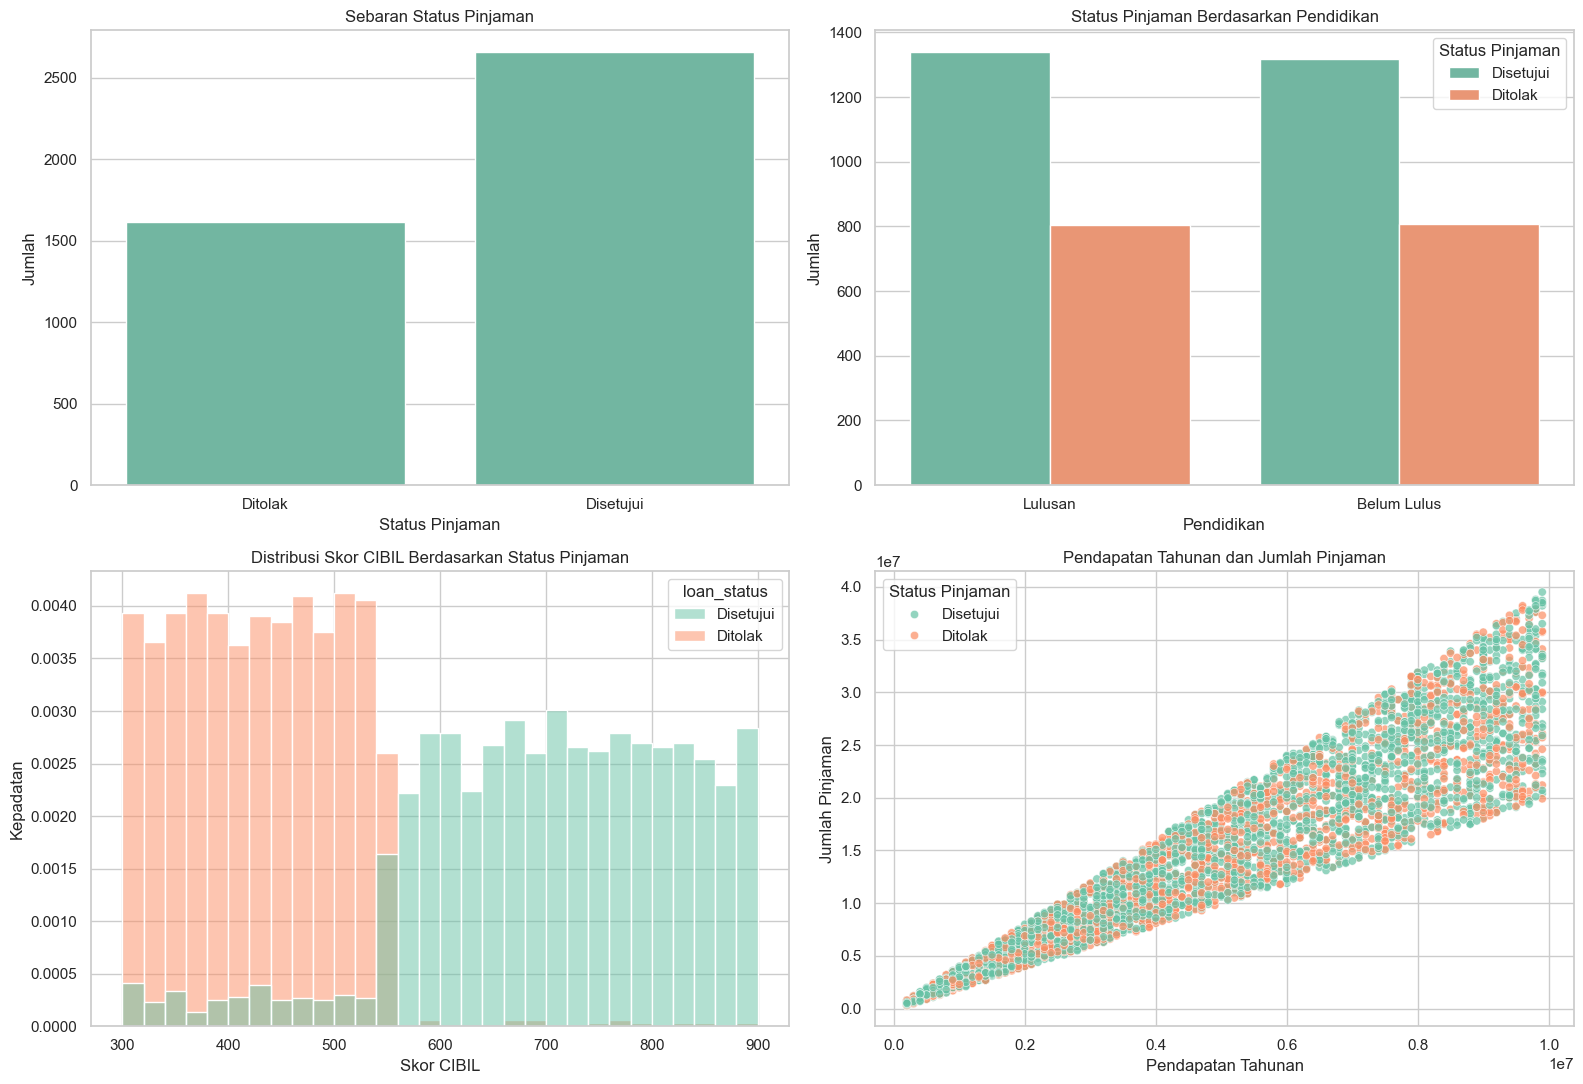

In [4]:
data_visualisasi_eda = data_eda.copy()
data_visualisasi_eda["loan_status"] = data_visualisasi_eda["loan_status"].replace(peta_status_tampilan)
data_visualisasi_eda["education"] = data_visualisasi_eda["education"].replace(peta_pendidikan_tampilan)
data_visualisasi_eda["self_employed"] = data_visualisasi_eda["self_employed"].replace(peta_status_mandiri_tampilan)

fig, sumbu = plt.subplots(2, 2, figsize=(16, 11))

sns.countplot(
    data=data_visualisasi_eda,
    x="loan_status",
    order=["Ditolak", "Disetujui"],
    ax=sumbu[0, 0],
)
sumbu[0, 0].set_title("Sebaran Status Pinjaman")
sumbu[0, 0].set_xlabel("Status Pinjaman")
sumbu[0, 0].set_ylabel("Jumlah")

sns.countplot(
    data=data_visualisasi_eda,
    x="education",
    hue="loan_status",
    ax=sumbu[0, 1],
)
sumbu[0, 1].set_title("Status Pinjaman Berdasarkan Pendidikan")
sumbu[0, 1].set_xlabel("Pendidikan")
sumbu[0, 1].set_ylabel("Jumlah")
legenda_pendidikan = sumbu[0, 1].legend(title="Status Pinjaman")
if legenda_pendidikan is not None:
    legenda_pendidikan.set_title("Status Pinjaman")

sns.histplot(
    data=data_visualisasi_eda,
    x="cibil_score",
    hue="loan_status",
    bins=30,
    stat="density",
    common_norm=False,
    ax=sumbu[1, 0],
)
sumbu[1, 0].set_title("Distribusi Skor CIBIL Berdasarkan Status Pinjaman")
sumbu[1, 0].set_xlabel("Skor CIBIL")
sumbu[1, 0].set_ylabel("Kepadatan")

sns.scatterplot(
    data=data_visualisasi_eda,
    x="income_annum",
    y="loan_amount",
    hue="loan_status",
    alpha=0.7,
    ax=sumbu[1, 1],
)
sumbu[1, 1].set_title("Pendapatan Tahunan dan Jumlah Pinjaman")
sumbu[1, 1].set_xlabel("Pendapatan Tahunan")
sumbu[1, 1].set_ylabel("Jumlah Pinjaman")
legenda_scatter = sumbu[1, 1].legend(title="Status Pinjaman")
if legenda_scatter is not None:
    legenda_scatter.set_title("Status Pinjaman")

plt.tight_layout()
plt.show()


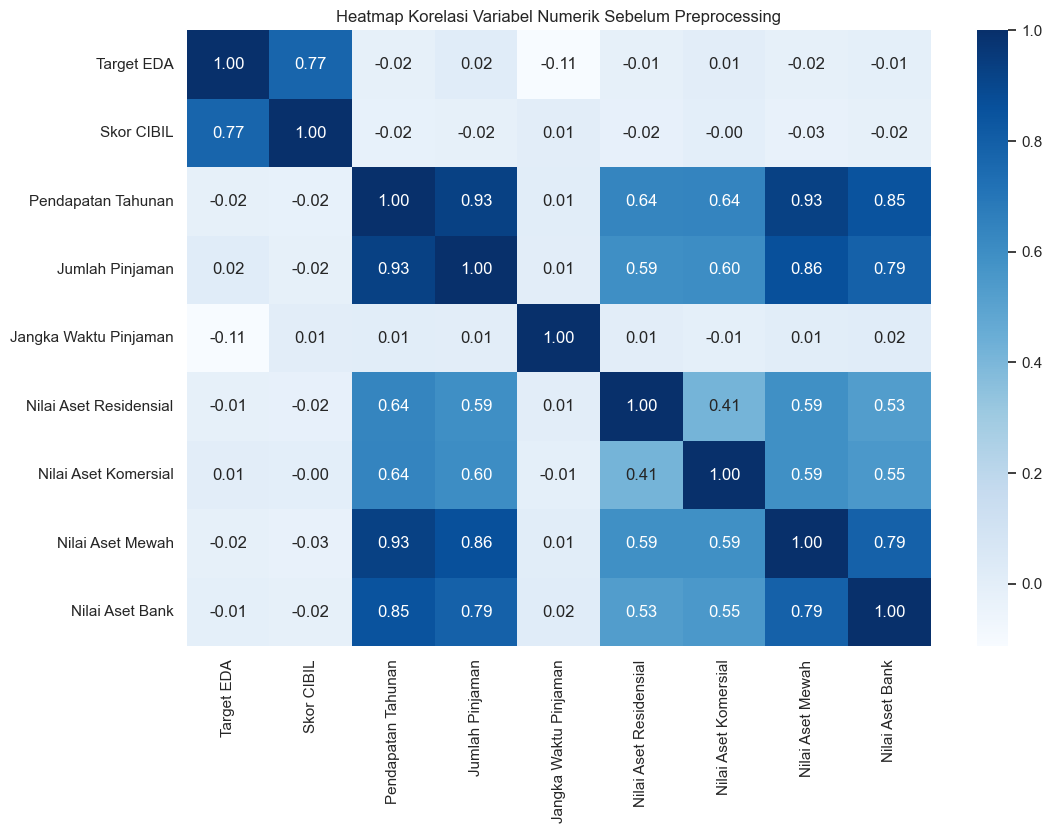

In [5]:
kolom_korelasi = [
    "target_eda",
    "cibil_score",
    "income_annum",
    "loan_amount",
    "loan_term",
    "residential_assets_value",
    "commercial_assets_value",
    "luxury_assets_value",
    "bank_asset_value",
]

matriks_korelasi = data_eda[kolom_korelasi].corr()
matriks_korelasi_tampilan = matriks_korelasi.rename(
    index=peta_nama_kolom_tampilan,
    columns=peta_nama_kolom_tampilan,
)

plt.figure(figsize=(12, 8))
sns.heatmap(matriks_korelasi_tampilan, annot=True, cmap="Blues", fmt=".2f")
plt.title("Heatmap Korelasi Variabel Numerik Sebelum Preprocessing")
plt.show()


## Preprocessing


Pada tahap preprocessing, penelitian ini menerapkan beberapa aturan penting agar hasil eksperimen tetap valid secara metodologis.

1. **Kolom identitas (`loan_id`) dihapus** agar model tidak belajar dari identitas unik.
2. **Fitur turunan dibuat hanya dari informasi baris yang sama** sehingga tidak terjadi kebocoran target.
3. **Nilai aset negatif disesuaikan menjadi nol** karena secara bisnis nilai aset negatif pada konteks ini tidak logis.
4. **Split data train/valid/test dilakukan sebelum fitting preprocessing** untuk mencegah data leakage.
5. **Imputer, scaler, dan encoder hanya di-fit pada data latih** melalui pipeline.

Dengan rancangan ini, potensi data leakage dapat ditekan seminimal mungkin.


In [6]:
def muat_dan_bersihkan_data(lokasi_file: Path) -> tuple[pd.DataFrame, int]:
    data = pd.read_csv(lokasi_file)
    data.columns = [kolom.strip() for kolom in data.columns]

    for kolom in ["education", "self_employed", "loan_status"]:
        data[kolom] = data[kolom].astype(str).str.strip()

    jumlah_aset_negatif = int((data[kolom_aset] < 0).sum().sum())
    data[kolom_aset] = data[kolom_aset].clip(lower=0)

    data["total_assets_value"] = data[kolom_aset].sum(axis=1)
    data["rasio_pinjaman_pendapatan"] = data["loan_amount"] / data["income_annum"]
    data["rasio_agunan_pinjaman"] = data["total_assets_value"] / data["loan_amount"]
    data["target_kelayakan"] = data["loan_status"].map({"Rejected": 0, "Approved": 1}).astype(int)

    return data, jumlah_aset_negatif


data_pinjaman, jumlah_aset_negatif = muat_dan_bersihkan_data(lokasi_dataset)

ringkasan_preprocessing = pd.DataFrame(
    {
        "komponen": [
            "Jumlah baris",
            "Jumlah kolom setelah rekayasa fitur",
            "Nilai hilang",
            "Data duplikat",
            "Nilai aset negatif yang disesuaikan menjadi 0",
        ],
        "nilai": [
            len(data_pinjaman),
            data_pinjaman.shape[1],
            int(data_pinjaman.isna().sum().sum()),
            int(data_pinjaman.duplicated().sum()),
            jumlah_aset_negatif,
        ],
    }
)

data_tampilan_preprocessing = data_pinjaman.head().copy()
data_tampilan_preprocessing["education"] = data_tampilan_preprocessing["education"].replace(peta_pendidikan_tampilan)
data_tampilan_preprocessing["self_employed"] = data_tampilan_preprocessing["self_employed"].replace(peta_status_mandiri_tampilan)
data_tampilan_preprocessing["loan_status"] = data_tampilan_preprocessing["loan_status"].replace(peta_status_tampilan)

display(data_tampilan_preprocessing.rename(columns=peta_nama_kolom_tampilan))
display(ringkasan_preprocessing)


,ID Pinjaman,Jumlah Tanggungan,Pendidikan,Pekerjaan Mandiri,Pendapatan Tahunan,Jumlah Pinjaman,Jangka Waktu Pinjaman,Skor CIBIL,Nilai Aset Residensial,Nilai Aset Komersial,Nilai Aset Mewah,Nilai Aset Bank,Status Pinjaman,Total Nilai Aset,Rasio Pinjaman terhadap Pendapatan,Rasio Agunan terhadap Pinjaman,Target Kelayakan
0,1,2,Lulusan,Tidak,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Disetujui,50700000,3.1146,1.6957,1
1,2,0,Belum Lulus,Ya,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Ditolak,17000000,2.9756,1.3934,0
2,3,3,Lulusan,Tidak,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Ditolak,57700000,3.2637,1.9428,0
3,4,3,Lulusan,Tidak,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Ditolak,52700000,3.7439,1.7166,0
4,5,5,Belum Lulus,Ya,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Ditolak,55000000,2.4694,2.2727,0


,komponen,nilai
0,Jumlah baris,4269
1,Jumlah kolom setelah rekayasa fitur,17
2,Nilai hilang,0
3,Data duplikat,0
4,Nilai aset negatif yang disesuaikan menjadi 0,28


## Pretraining


Tahap pretraining berisi rancangan eksperimen sebelum model dilatih:

- Data dibagi menjadi **kumpulan latih 80%** dan **uji 20%**.
- Data kumpulan latih kemudian dipecah lagi menjadi **latih 60%** dan **validasi 20%**.
- Data uji **tidak digunakan** untuk preprocessing, seleksi parameter, maupun validasi.
- Evaluasi overfitting dilakukan dengan membandingkan **F1-Score latih, validasi, dan uji**.
- Sebuah model dianggap **aman dari indikasi overfitting berat** apabila selisih `latih-uji` berada pada kisaran kecil, khususnya di bawah `0.02`.


In [7]:
fitur_model = data_pinjaman.drop(columns=["loan_id", "loan_status", "target_kelayakan"])
target_pemodelan = data_pinjaman["target_kelayakan"]

kolom_kategorikal = ["education", "self_employed"]
kolom_numerik = [kolom for kolom in fitur_model.columns if kolom not in kolom_kategorikal]

X_kumpulan_latih, X_uji, y_kumpulan_latih, y_uji = train_test_split(
    fitur_model,
    target_pemodelan,
    test_size=0.20,
    random_state=BENIH_ACAK,
    stratify=target_pemodelan,
)

X_latih, X_validasi, y_latih, y_validasi = train_test_split(
    X_kumpulan_latih,
    y_kumpulan_latih,
    test_size=0.25,
    random_state=BENIH_ACAK,
    stratify=y_kumpulan_latih,
)


def buat_encoder_one_hot():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def buat_preprosesor_logistik() -> ColumnTransformer:
    return ColumnTransformer(
        transformers=[
            (
                "numerik",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="median")),
                        ("scaler", StandardScaler()),
                    ]
                ),
                kolom_numerik,
            ),
            (
                "kategori",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="most_frequent")),
                        ("encoder", buat_encoder_one_hot()),
                    ]
                ),
                kolom_kategorikal,
            ),
        ],
        remainder="drop",
    )


def buat_preprosesor_pohon() -> ColumnTransformer:
    return ColumnTransformer(
        transformers=[
            (
                "numerik",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="median")),
                    ]
                ),
                kolom_numerik,
            ),
            (
                "kategori",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="most_frequent")),
                        ("encoder", buat_encoder_one_hot()),
                    ]
                ),
                kolom_kategorikal,
            ),
        ],
        remainder="drop",
    )


def siapkan_data_catboost(data_input: pd.DataFrame, data_acuan: pd.DataFrame) -> pd.DataFrame:
    hasil_data = data_input.copy()

    for kolom in kolom_numerik:
        hasil_data[kolom] = hasil_data[kolom].fillna(data_acuan[kolom].median())

    for kolom in kolom_kategorikal:
        hasil_data[kolom] = hasil_data[kolom].fillna(data_acuan[kolom].mode().iloc[0]).astype(str)

    return hasil_data


def hitung_metrik_dari_probabilitas(y_asli: pd.Series, probabilitas: np.ndarray) -> dict[str, float]:
    prediksi_label = (probabilitas >= 0.5).astype(int)

    return {
        "akurasi": accuracy_score(y_asli, prediksi_label),
        "presisi": precision_score(y_asli, prediksi_label),
        "recall": recall_score(y_asli, prediksi_label),
        "f1": f1_score(y_asli, prediksi_label),
        "roc_auc": roc_auc_score(y_asli, probabilitas),
    }


def status_overfitting(gap_nilai: float) -> str:
    return "Aman" if gap_nilai <= 0.02 else "Perlu perhatian"


def tampilkan_matriks_kebingungan(
    kumpulan_prediksi: dict[str, np.ndarray],
    y_asli: pd.Series,
    judul_grafik: str,
) -> None:
    fig, sumbu = plt.subplots(2, 2, figsize=(12, 10))
    daftar_sumbu = sumbu.flatten()

    for indeks, (nama_model, prediksi_label) in enumerate(kumpulan_prediksi.items()):
        ConfusionMatrixDisplay.from_predictions(
            y_asli,
            prediksi_label,
            display_labels=["Ditolak", "Disetujui"],
            cmap="Blues",
            colorbar=False,
            ax=daftar_sumbu[indeks],
        )
        daftar_sumbu[indeks].set_title(nama_model)

    fig.suptitle(judul_grafik, fontsize=14)
    plt.tight_layout()
    plt.show()


def tampilkan_kurva_roc(
    kumpulan_probabilitas: dict[str, np.ndarray],
    y_asli: pd.Series,
    judul_grafik: str,
) -> None:
    plt.figure(figsize=(9, 7))

    for nama_model, probabilitas in kumpulan_probabilitas.items():
        RocCurveDisplay.from_predictions(
            y_asli,
            probabilitas,
            name=nama_model,
        )

    plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
    plt.title(judul_grafik)
    plt.show()


daftar_periksa_kebocoran_data = pd.DataFrame(
    {
        "poin_pemeriksaan": [
            "Kolom identitas dihapus dari fitur",
            "Split data dilakukan sebelum fitting preprocessing",
            "Imputer, scaler, dan encoder di-fit hanya pada data latih",
            "Data validasi dipisahkan dari data uji",
            "Penyetelan hiperparameter tidak menggunakan data uji",
        ],
        "status": ["Ya", "Ya", "Ya", "Ya", "Ya"],
        "keterangan": [
            "loan_id tidak diikutkan ke model",
            "train/valid/test dipisah di awal",
            "diterapkan melalui Pipeline dan ColumnTransformer",
            "validasi untuk seleksi model, uji untuk evaluasi akhir",
            "pemilihan parameter hanya pada train + validasi",
        ],
    }
)

ringkasan_prapelatihan = pd.DataFrame(
    {
        "komponen": [
            "Jumlah data latih",
            "Jumlah data validasi",
            "Jumlah data uji",
            "Jumlah fitur numerik",
            "Jumlah fitur kategorikal",
        ],
        "nilai": [
            len(X_latih),
            len(X_validasi),
            len(X_uji),
            len(kolom_numerik),
            len(kolom_kategorikal),
        ],
    }
)

display(ringkasan_prapelatihan)
display(daftar_periksa_kebocoran_data)


,komponen,nilai
0,Jumlah data latih,2561
1,Jumlah data validasi,854
2,Jumlah data uji,854
3,Jumlah fitur numerik,12
4,Jumlah fitur kategorikal,2


,poin_pemeriksaan,status,keterangan
0,Kolom identitas dihapus dari fitur,Ya,loan_id tidak diikutkan ke model
1,Split data dilakukan sebelum fitting preproces...,Ya,train/valid/test dipisah di awal
2,"Imputer, scaler, dan encoder di-fit hanya pada...",Ya,diterapkan melalui Pipeline dan ColumnTransformer
3,Data validasi dipisahkan dari data uji,Ya,"validasi untuk seleksi model, uji untuk evalua..."
4,Penyetelan hiperparameter tidak menggunakan da...,Ya,pemilihan parameter hanya pada train + validasi


## Pelatihan


In [8]:
lipatan_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=BENIH_ACAK)


def evaluasi_model_pipeline(
    nama_model: str,
    model: Pipeline,
    X_data_latih: pd.DataFrame,
    y_data_latih: pd.Series,
    X_data_validasi: pd.DataFrame,
    y_data_validasi: pd.Series,
    hitung_cv: bool = True,
) -> dict[str, object]:
    model.fit(X_data_latih, y_data_latih)

    probabilitas_latih = model.predict_proba(X_data_latih)[:, 1]
    probabilitas_validasi = model.predict_proba(X_data_validasi)[:, 1]

    metrik_latih = hitung_metrik_dari_probabilitas(y_data_latih, probabilitas_latih)
    metrik_validasi = hitung_metrik_dari_probabilitas(y_data_validasi, probabilitas_validasi)

    skor_cv = np.nan
    if hitung_cv:
        skor_cv = cross_val_score(
            model,
            X_data_latih,
            y_data_latih,
            cv=lipatan_cv,
            scoring="f1",
            n_jobs=1,
        ).mean()

    gap_latih_validasi = abs(metrik_latih["f1"] - metrik_validasi["f1"])

    return {
        "model": nama_model,
        "validasi_silang_f1": skor_cv,
        "akurasi_latih": metrik_latih["akurasi"],
        "akurasi_validasi": metrik_validasi["akurasi"],
        "f1_latih": metrik_latih["f1"],
        "f1_validasi": metrik_validasi["f1"],
        "roc_auc_validasi": metrik_validasi["roc_auc"],
        "selisih_latih_validasi": gap_latih_validasi,
        "status_overfitting": status_overfitting(gap_latih_validasi),
        "probabilitas_validasi": probabilitas_validasi,
        "prediksi_validasi": (probabilitas_validasi >= 0.5).astype(int),
        "model_objek": model,
    }


def evaluasi_model_catboost(
    nama_model: str,
    parameter: dict[str, object],
    X_data_latih: pd.DataFrame,
    y_data_latih: pd.Series,
    X_data_validasi: pd.DataFrame,
    y_data_validasi: pd.Series,
) -> dict[str, object]:
    model = CatBoostClassifier(
        loss_function="Logloss",
        eval_metric="F1",
        random_seed=BENIH_ACAK,
        verbose=0,
        allow_writing_files=False,
        **parameter,
    )

    model.fit(
        X_data_latih,
        y_data_latih,
        cat_features=kolom_kategorikal,
        eval_set=(X_data_validasi, y_data_validasi),
        use_best_model=True,
    )

    probabilitas_latih = model.predict_proba(X_data_latih)[:, 1]
    probabilitas_validasi = model.predict_proba(X_data_validasi)[:, 1]

    metrik_latih = hitung_metrik_dari_probabilitas(y_data_latih, probabilitas_latih)
    metrik_validasi = hitung_metrik_dari_probabilitas(y_data_validasi, probabilitas_validasi)

    gap_latih_validasi = abs(metrik_latih["f1"] - metrik_validasi["f1"])

    return {
        "model": nama_model,
        "validasi_silang_f1": np.nan,
        "akurasi_latih": metrik_latih["akurasi"],
        "akurasi_validasi": metrik_validasi["akurasi"],
        "f1_latih": metrik_latih["f1"],
        "f1_validasi": metrik_validasi["f1"],
        "roc_auc_validasi": metrik_validasi["roc_auc"],
        "selisih_latih_validasi": gap_latih_validasi,
        "status_overfitting": status_overfitting(gap_latih_validasi),
        "probabilitas_validasi": probabilitas_validasi,
        "prediksi_validasi": (probabilitas_validasi >= 0.5).astype(int),
        "model_objek": model,
    }


konfigurasi_dasar = {
    "Logistic Regression": Pipeline(
        steps=[
            ("preprosesor", buat_preprosesor_logistik()),
            ("model", LogisticRegression(max_iter=3000, random_state=BENIH_ACAK)),
        ]
    ),
    "Random Forest": Pipeline(
        steps=[
            ("preprosesor", buat_preprosesor_pohon()),
            (
                "model",
                RandomForestClassifier(
                    n_estimators=150,
                    max_depth=5,
                    min_samples_leaf=10,
                    random_state=BENIH_ACAK,
                    n_jobs=1,
                ),
            ),
        ]
    ),
    "LightGBM": Pipeline(
        steps=[
            ("preprosesor", buat_preprosesor_pohon()),
            (
                "model",
                LGBMClassifier(
                    n_estimators=100,
                    learning_rate=0.05,
                    num_leaves=15,
                    max_depth=3,
                    min_child_samples=50,
                    subsample=0.8,
                    colsample_bytree=0.8,
                    objective="binary",
                    verbose=-1,
                    random_state=BENIH_ACAK,
                ),
            ),
        ]
    ),
}

hasil_validasi_dasar = []
probabilitas_validasi_dasar = {}
prediksi_validasi_dasar = {}

for nama_model, model in konfigurasi_dasar.items():
    hasil_model = evaluasi_model_pipeline(
        nama_model=nama_model,
        model=model,
        X_data_latih=X_latih,
        y_data_latih=y_latih,
        X_data_validasi=X_validasi,
        y_data_validasi=y_validasi,
    )
    hasil_validasi_dasar.append(hasil_model)
    probabilitas_validasi_dasar[nama_model] = hasil_model["probabilitas_validasi"]
    prediksi_validasi_dasar[nama_model] = hasil_model["prediksi_validasi"]

X_latih_cat = siapkan_data_catboost(X_latih, X_latih)
X_validasi_cat = siapkan_data_catboost(X_validasi, X_latih)

parameter_catboost_dasar = {
    "depth": 4,
    "iterations": 100,
    "learning_rate": 0.05,
    "l2_leaf_reg": 7,
}

hasil_catboost_dasar = evaluasi_model_catboost(
    nama_model="CatBoost",
    parameter=parameter_catboost_dasar,
    X_data_latih=X_latih_cat,
    y_data_latih=y_latih,
    X_data_validasi=X_validasi_cat,
    y_data_validasi=y_validasi,
)

hasil_validasi_dasar.append(hasil_catboost_dasar)
probabilitas_validasi_dasar["CatBoost"] = hasil_catboost_dasar["probabilitas_validasi"]
prediksi_validasi_dasar["CatBoost"] = hasil_catboost_dasar["prediksi_validasi"]

hasil_validasi_dasar_df = (
    pd.DataFrame(hasil_validasi_dasar)
    .drop(columns=["probabilitas_validasi", "prediksi_validasi", "model_objek"])
    .sort_values(["f1_validasi", "roc_auc_validasi"], ascending=False)
    .reset_index(drop=True)
)


def evaluasi_akhir_pipeline(
    nama_model: str,
    model: Pipeline,
    X_data_kumpulan_latih: pd.DataFrame,
    y_data_kumpulan_latih: pd.Series,
    X_data_uji: pd.DataFrame,
    y_data_uji: pd.Series,
) -> dict[str, object]:
    model.fit(X_data_kumpulan_latih, y_data_kumpulan_latih)
    probabilitas_kumpulan_latih = model.predict_proba(X_data_kumpulan_latih)[:, 1]
    probabilitas_uji = model.predict_proba(X_data_uji)[:, 1]

    metrik_kumpulan_latih = hitung_metrik_dari_probabilitas(y_data_kumpulan_latih, probabilitas_kumpulan_latih)
    metrik_uji = hitung_metrik_dari_probabilitas(y_data_uji, probabilitas_uji)

    gap_latih_uji = abs(metrik_kumpulan_latih["f1"] - metrik_uji["f1"])

    return {
        "model": nama_model,
        "tahap": "Baseline",
        "akurasi_kumpulan_latih": metrik_kumpulan_latih["akurasi"],
        "akurasi_uji": metrik_uji["akurasi"],
        "presisi_uji": metrik_uji["presisi"],
        "recall_uji": metrik_uji["recall"],
        "f1_kumpulan_latih": metrik_kumpulan_latih["f1"],
        "f1_uji": metrik_uji["f1"],
        "roc_auc_uji": metrik_uji["roc_auc"],
        "selisih_latih_uji": gap_latih_uji,
        "status_overfitting_uji": status_overfitting(gap_latih_uji),
        "prediksi_uji": (probabilitas_uji >= 0.5).astype(int),
        "probabilitas_uji": probabilitas_uji,
        "model_objek": model,
        "parameter_terbaik": "default baseline",
    }


def evaluasi_akhir_catboost(
    nama_model: str,
    parameter: dict[str, object],
    X_data_kumpulan_latih: pd.DataFrame,
    y_data_kumpulan_latih: pd.Series,
    X_data_uji: pd.DataFrame,
    y_data_uji: pd.Series,
) -> dict[str, object]:
    model = CatBoostClassifier(
        loss_function="Logloss",
        eval_metric="F1",
        random_seed=BENIH_ACAK,
        verbose=0,
        allow_writing_files=False,
        **parameter,
    )

    model.fit(X_data_kumpulan_latih, y_data_kumpulan_latih, cat_features=kolom_kategorikal)

    probabilitas_kumpulan_latih = model.predict_proba(X_data_kumpulan_latih)[:, 1]
    probabilitas_uji = model.predict_proba(X_data_uji)[:, 1]

    metrik_kumpulan_latih = hitung_metrik_dari_probabilitas(y_data_kumpulan_latih, probabilitas_kumpulan_latih)
    metrik_uji = hitung_metrik_dari_probabilitas(y_data_uji, probabilitas_uji)

    gap_latih_uji = abs(metrik_kumpulan_latih["f1"] - metrik_uji["f1"])

    return {
        "model": nama_model,
        "tahap": "Baseline",
        "akurasi_kumpulan_latih": metrik_kumpulan_latih["akurasi"],
        "akurasi_uji": metrik_uji["akurasi"],
        "presisi_uji": metrik_uji["presisi"],
        "recall_uji": metrik_uji["recall"],
        "f1_kumpulan_latih": metrik_kumpulan_latih["f1"],
        "f1_uji": metrik_uji["f1"],
        "roc_auc_uji": metrik_uji["roc_auc"],
        "selisih_latih_uji": gap_latih_uji,
        "status_overfitting_uji": status_overfitting(gap_latih_uji),
        "prediksi_uji": (probabilitas_uji >= 0.5).astype(int),
        "probabilitas_uji": probabilitas_uji,
        "model_objek": model,
        "parameter_terbaik": str(parameter),
    }


hasil_akhir_dasar = []
probabilitas_uji_dasar = {}
prediksi_uji_dasar = {}
model_akhir_dasar = {}

for nama_model, model in konfigurasi_dasar.items():
    hasil_model = evaluasi_akhir_pipeline(
        nama_model=nama_model,
        model=model,
        X_data_kumpulan_latih=X_kumpulan_latih,
        y_data_kumpulan_latih=y_kumpulan_latih,
        X_data_uji=X_uji,
        y_data_uji=y_uji,
    )
    hasil_akhir_dasar.append(hasil_model)
    probabilitas_uji_dasar[nama_model] = hasil_model["probabilitas_uji"]
    prediksi_uji_dasar[nama_model] = hasil_model["prediksi_uji"]
    model_akhir_dasar[nama_model] = hasil_model["model_objek"]

X_kumpulan_latih_cat = siapkan_data_catboost(X_kumpulan_latih, X_kumpulan_latih)
X_uji_cat = siapkan_data_catboost(X_uji, X_kumpulan_latih)

hasil_catboost_akhir_dasar = evaluasi_akhir_catboost(
    nama_model="CatBoost",
    parameter=parameter_catboost_dasar,
    X_data_kumpulan_latih=X_kumpulan_latih_cat,
    y_data_kumpulan_latih=y_kumpulan_latih,
    X_data_uji=X_uji_cat,
    y_data_uji=y_uji,
)

hasil_akhir_dasar.append(hasil_catboost_akhir_dasar)
probabilitas_uji_dasar["CatBoost"] = hasil_catboost_akhir_dasar["probabilitas_uji"]
prediksi_uji_dasar["CatBoost"] = hasil_catboost_akhir_dasar["prediksi_uji"]
model_akhir_dasar["CatBoost"] = hasil_catboost_akhir_dasar["model_objek"]

hasil_akhir_dasar_df = (
    pd.DataFrame(hasil_akhir_dasar)
    .drop(columns=["prediksi_uji", "probabilitas_uji", "model_objek"])
    .sort_values(["f1_uji", "roc_auc_uji", "akurasi_uji"], ascending=False)
    .reset_index(drop=True)
)


## Hasil


,model,validasi_silang_f1,akurasi_latih,akurasi_validasi,f1_latih,f1_validasi,roc_auc_validasi,selisih_latih_validasi,status_overfitting
0,Random Forest,0.9969,0.9969,0.9953,0.9975,0.9962,0.9995,0.0012,Aman
1,CatBoost,NaN,0.9969,0.9953,0.9975,0.9962,0.9971,0.0012,Aman
2,LightGBM,0.9984,0.9969,0.9941,0.9975,0.9953,0.9999,0.0022,Aman
3,Logistic Regression,0.9321,0.9200,0.8923,0.9356,0.9135,0.9585,0.0221,Perlu perhatian


,model,tahap,akurasi_kumpulan_latih,akurasi_uji,presisi_uji,recall_uji,f1_kumpulan_latih,f1_uji,roc_auc_uji,selisih_latih_uji,status_overfitting_uji,parameter_terbaik
0,LightGBM,Baseline,0.9988,0.9965,0.9944,1.0000,0.9991,0.9972,1.0000,0.0019,Aman,default baseline
1,Random Forest,Baseline,0.9965,0.9953,0.9925,1.0000,0.9972,0.9962,0.9999,0.0009,Aman,default baseline
2,CatBoost,Baseline,0.9965,0.9953,0.9925,1.0000,0.9972,0.9962,0.9997,0.0009,Aman,"{'depth': 4, 'iterations': 100, 'learning_rate..."
3,Logistic Regression,Baseline,0.9136,0.9133,0.9193,0.9435,0.9306,0.9312,0.9728,0.0006,Aman,default baseline


**Tabel Hasil Baseline pada Data Uji**

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,LightGBM,0.9965,0.9944,1.0000,0.9972,1.0000
1,Random Forest,0.9953,0.9925,1.0000,0.9962,0.9999
2,CatBoost,0.9953,0.9925,1.0000,0.9962,0.9997
3,Logistic Regression,0.9133,0.9193,0.9435,0.9312,0.9728


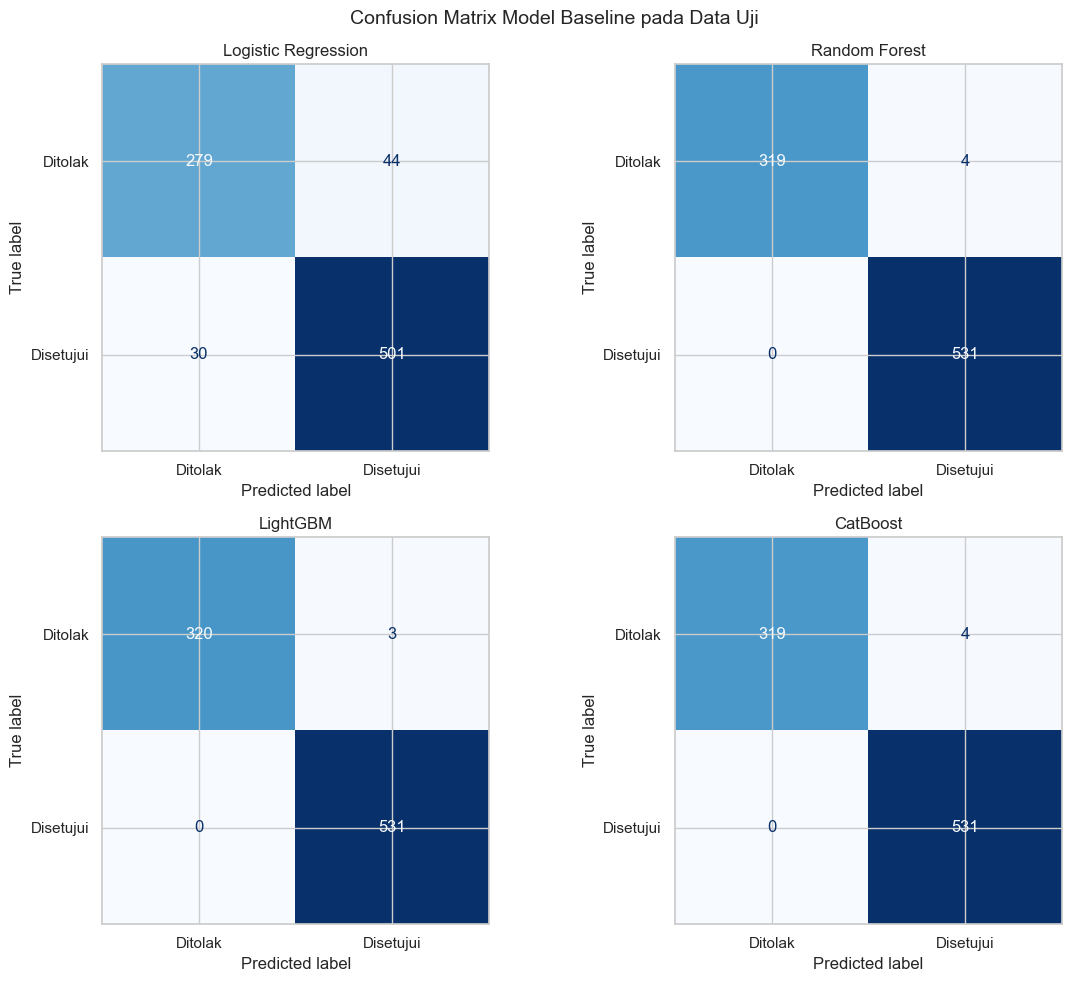

<Figure size 900x700 with 0 Axes>

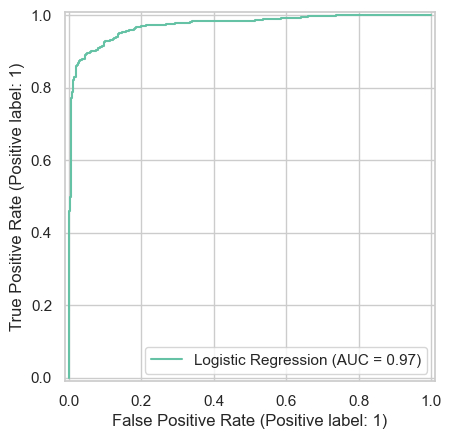

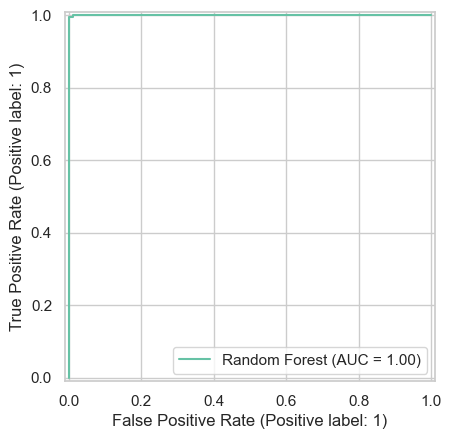

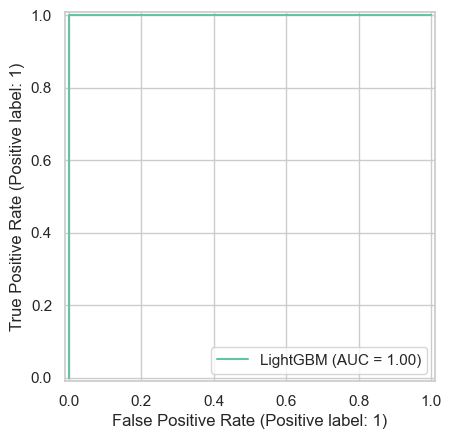

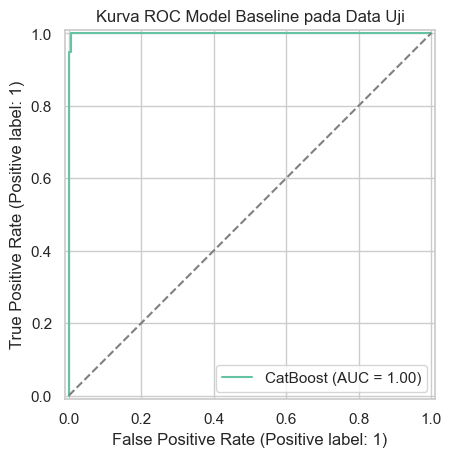

In [9]:
display(hasil_validasi_dasar_df.round(4))
display(hasil_akhir_dasar_df.round(4))


# ── Tabel Hasil Baseline pada Data Uji (ringkasan bersih) ──
display(Markdown('**Tabel Hasil Baseline pada Data Uji**'))
tabel_baseline_uji = hasil_akhir_dasar_df[[
    'model', 'akurasi_uji', 'presisi_uji', 'recall_uji', 'f1_uji', 'roc_auc_uji'
]].copy()
tabel_baseline_uji.columns = ['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
tabel_baseline_uji = tabel_baseline_uji.reset_index(drop=True)
display(tabel_baseline_uji.round(4))
tampilkan_matriks_kebingungan(
    kumpulan_prediksi=prediksi_uji_dasar,
    y_asli=y_uji,
    judul_grafik="Confusion Matrix Model Baseline pada Data Uji",
)

tampilkan_kurva_roc(
    kumpulan_probabilitas=probabilitas_uji_dasar,
    y_asli=y_uji,
    judul_grafik="Kurva ROC Model Baseline pada Data Uji",
)


## Perbandingan


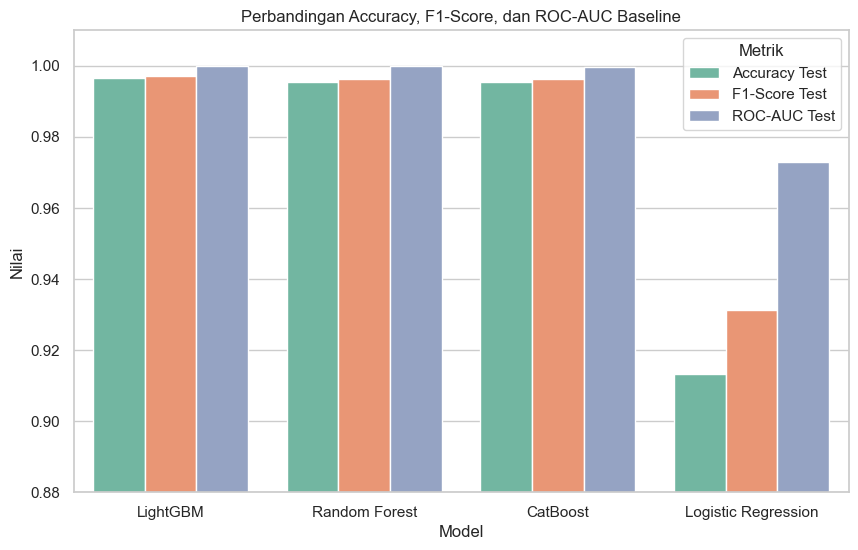

In [10]:
data_plot_dasar = hasil_akhir_dasar_df.melt(
    id_vars=["model"],
    value_vars=["akurasi_uji", "f1_uji", "roc_auc_uji"],
    var_name="metrik",
    value_name="nilai",
)
data_plot_dasar["metrik"] = data_plot_dasar["metrik"].replace(
    {
        "akurasi_uji": "Accuracy Test",
        "f1_uji": "F1-Score Test",
        "roc_auc_uji": "ROC-AUC Test",
    }
)

plt.figure(figsize=(10, 6))
sns.barplot(data=data_plot_dasar, x="model", y="nilai", hue="metrik")
plt.ylim(0.88, 1.01)
plt.title("Perbandingan Accuracy, F1-Score, dan ROC-AUC Baseline")
plt.xlabel("Model")
plt.ylabel("Nilai")
plt.legend(title="Metrik")
plt.show()


## Rangkuman


In [11]:
model_terbaik_dasar = hasil_akhir_dasar_df.iloc[0]
model_terendah_dasar = hasil_akhir_dasar_df.sort_values("f1_uji").iloc[0]
jumlah_model_aman_dasar = (hasil_akhir_dasar_df["status_overfitting_uji"] == "Aman").sum()

display(
    Markdown(
        f'''
Pada tahap baseline, model **{model_terbaik_dasar["model"]}** menjadi model dengan performa tertinggi pada data uji dengan **akurasi = {model_terbaik_dasar["akurasi_uji"]:.4f}**, **F1-Score = {model_terbaik_dasar["f1_uji"]:.4f}**, dan **ROC-AUC = {model_terbaik_dasar["roc_auc_uji"]:.4f}**.

Model dengan performa terendah pada tahap baseline adalah **{model_terendah_dasar["model"]}**. Meskipun demikian, seluruh model baseline masih menunjukkan performa tinggi.

Dari sisi generalisasi, **{jumlah_model_aman_dasar} dari 4 model baseline** masuk kategori **aman** berdasarkan gap `latih-uji` yang kecil. Hal ini menunjukkan bahwa rancangan eksperimen tidak memperlihatkan indikasi overfitting berat.
        '''
    )
)



Pada tahap baseline, model **LightGBM** menjadi model dengan performa tertinggi pada data uji dengan **akurasi = 0.9965**, **F1-Score = 0.9972**, dan **ROC-AUC = 1.0000**.

Model dengan performa terendah pada tahap baseline adalah **Logistic Regression**. Meskipun demikian, seluruh model baseline masih menunjukkan performa tinggi.

Dari sisi generalisasi, **4 dari 4 model baseline** masuk kategori **aman** berdasarkan gap `latih-uji` yang kecil. Hal ini menunjukkan bahwa rancangan eksperimen tidak memperlihatkan indikasi overfitting berat.
        

## Hyperparameter Tuning


In [12]:
kandidat_logistik = [
    {"C": 0.05, "class_weight": None},
    {"C": 0.10, "class_weight": "balanced"},
    {"C": 0.50, "class_weight": "balanced"},
    {"C": 1.00, "class_weight": None},
]

kandidat_random_forest = [
    {"n_estimators": 150, "max_depth": 5, "min_samples_leaf": 10, "max_features": "sqrt", "class_weight": None},
    {"n_estimators": 250, "max_depth": 8, "min_samples_leaf": 10, "max_features": "sqrt", "class_weight": "balanced"},
    {"n_estimators": 300, "max_depth": 8, "min_samples_leaf": 5, "max_features": "sqrt", "class_weight": "balanced"},
    {"n_estimators": 400, "max_depth": 10, "min_samples_leaf": 5, "max_features": "sqrt", "class_weight": "balanced"},
]

kandidat_lightgbm = [
    {"n_estimators": 100, "learning_rate": 0.05, "num_leaves": 15, "max_depth": 3, "min_child_samples": 50, "subsample": 0.8, "colsample_bytree": 0.8, "reg_alpha": 0.0, "reg_lambda": 0.0},
    {"n_estimators": 150, "learning_rate": 0.03, "num_leaves": 15, "max_depth": 3, "min_child_samples": 50, "subsample": 0.8, "colsample_bytree": 0.8, "reg_alpha": 0.5, "reg_lambda": 1.0},
    {"n_estimators": 150, "learning_rate": 0.05, "num_leaves": 31, "max_depth": 5, "min_child_samples": 50, "subsample": 0.8, "colsample_bytree": 0.8, "reg_alpha": 0.0, "reg_lambda": 1.0},
    {"n_estimators": 200, "learning_rate": 0.03, "num_leaves": 15, "max_depth": 3, "min_child_samples": 80, "subsample": 0.8, "colsample_bytree": 0.8, "reg_alpha": 0.5, "reg_lambda": 1.0},
]

kandidat_catboost = [
    {"depth": 4, "iterations": 100, "learning_rate": 0.05, "l2_leaf_reg": 7, "random_strength": 1},
    {"depth": 4, "iterations": 150, "learning_rate": 0.03, "l2_leaf_reg": 7, "random_strength": 3},
    {"depth": 6, "iterations": 150, "learning_rate": 0.03, "l2_leaf_reg": 7, "random_strength": 3},
    {"depth": 4, "iterations": 200, "learning_rate": 0.03, "l2_leaf_reg": 5, "random_strength": 3},
]


def skor_seleksi_model(hasil_model: dict[str, object]) -> float:
    validasi_silang_f1 = 0.0 if pd.isna(hasil_model["validasi_silang_f1"]) else hasil_model["validasi_silang_f1"]
    return hasil_model["f1_validasi"] + (0.20 * validasi_silang_f1) - (0.50 * hasil_model["selisih_latih_validasi"])


hasil_penyetelan_logistik = []
for parameter in kandidat_logistik:
    model = Pipeline(
        steps=[
            ("preprosesor", buat_preprosesor_logistik()),
            (
                "model",
                LogisticRegression(
                    max_iter=4000,
                    random_state=BENIH_ACAK,
                    solver="lbfgs",
                    **parameter,
                ),
            ),
        ]
    )
    hasil_model = evaluasi_model_pipeline(
        nama_model="Logistic Regression",
        model=model,
        X_data_latih=X_latih,
        y_data_latih=y_latih,
        X_data_validasi=X_validasi,
        y_data_validasi=y_validasi,
    )
    hasil_model["parameter"] = parameter
    hasil_model["skor_seleksi"] = skor_seleksi_model(hasil_model)
    hasil_penyetelan_logistik.append(hasil_model)

hasil_penyetelan_random_forest = []
for parameter in kandidat_random_forest:
    model = Pipeline(
        steps=[
            ("preprosesor", buat_preprosesor_pohon()),
            (
                "model",
                RandomForestClassifier(
                    random_state=BENIH_ACAK,
                    n_jobs=1,
                    **parameter,
                ),
            ),
        ]
    )
    hasil_model = evaluasi_model_pipeline(
        nama_model="Random Forest",
        model=model,
        X_data_latih=X_latih,
        y_data_latih=y_latih,
        X_data_validasi=X_validasi,
        y_data_validasi=y_validasi,
    )
    hasil_model["parameter"] = parameter
    hasil_model["skor_seleksi"] = skor_seleksi_model(hasil_model)
    hasil_penyetelan_random_forest.append(hasil_model)

hasil_penyetelan_lightgbm = []
for parameter in kandidat_lightgbm:
    model = Pipeline(
        steps=[
            ("preprosesor", buat_preprosesor_pohon()),
            (
                "model",
                LGBMClassifier(
                    objective="binary",
                    verbose=-1,
                    random_state=BENIH_ACAK,
                    **parameter,
                ),
            ),
        ]
    )
    hasil_model = evaluasi_model_pipeline(
        nama_model="LightGBM",
        model=model,
        X_data_latih=X_latih,
        y_data_latih=y_latih,
        X_data_validasi=X_validasi,
        y_data_validasi=y_validasi,
    )
    hasil_model["parameter"] = parameter
    hasil_model["skor_seleksi"] = skor_seleksi_model(hasil_model)
    hasil_penyetelan_lightgbm.append(hasil_model)

hasil_penyetelan_catboost = []
for parameter in kandidat_catboost:
    hasil_model = evaluasi_model_catboost(
        nama_model="CatBoost",
        parameter=parameter,
        X_data_latih=X_latih_cat,
        y_data_latih=y_latih,
        X_data_validasi=X_validasi_cat,
        y_data_validasi=y_validasi,
    )
    hasil_model["parameter"] = parameter
    hasil_model["skor_seleksi"] = skor_seleksi_model(hasil_model)
    hasil_penyetelan_catboost.append(hasil_model)

terbaik_logistik = max(hasil_penyetelan_logistik, key=lambda item: item["skor_seleksi"])
terbaik_random_forest = max(hasil_penyetelan_random_forest, key=lambda item: item["skor_seleksi"])
terbaik_lightgbm = max(hasil_penyetelan_lightgbm, key=lambda item: item["skor_seleksi"])
terbaik_catboost = max(hasil_penyetelan_catboost, key=lambda item: item["skor_seleksi"])

ringkasan_validasi_penyetelan = pd.DataFrame(
    [
        {
            "model": "Logistic Regression",
            "validasi_silang_f1": terbaik_logistik["validasi_silang_f1"],
            "f1_latih": terbaik_logistik["f1_latih"],
            "f1_validasi": terbaik_logistik["f1_validasi"],
            "selisih_latih_validasi": terbaik_logistik["selisih_latih_validasi"],
            "status_overfitting": terbaik_logistik["status_overfitting"],
            "parameter_terbaik": str(terbaik_logistik["parameter"]),
        },
        {
            "model": "Random Forest",
            "validasi_silang_f1": terbaik_random_forest["validasi_silang_f1"],
            "f1_latih": terbaik_random_forest["f1_latih"],
            "f1_validasi": terbaik_random_forest["f1_validasi"],
            "selisih_latih_validasi": terbaik_random_forest["selisih_latih_validasi"],
            "status_overfitting": terbaik_random_forest["status_overfitting"],
            "parameter_terbaik": str(terbaik_random_forest["parameter"]),
        },
        {
            "model": "LightGBM",
            "validasi_silang_f1": terbaik_lightgbm["validasi_silang_f1"],
            "f1_latih": terbaik_lightgbm["f1_latih"],
            "f1_validasi": terbaik_lightgbm["f1_validasi"],
            "selisih_latih_validasi": terbaik_lightgbm["selisih_latih_validasi"],
            "status_overfitting": terbaik_lightgbm["status_overfitting"],
            "parameter_terbaik": str(terbaik_lightgbm["parameter"]),
        },
        {
            "model": "CatBoost",
            "validasi_silang_f1": terbaik_catboost["validasi_silang_f1"],
            "f1_latih": terbaik_catboost["f1_latih"],
            "f1_validasi": terbaik_catboost["f1_validasi"],
            "selisih_latih_validasi": terbaik_catboost["selisih_latih_validasi"],
            "status_overfitting": terbaik_catboost["status_overfitting"],
            "parameter_terbaik": str(terbaik_catboost["parameter"]),
        },
    ]
).sort_values(["f1_validasi", "selisih_latih_validasi"], ascending=[False, True]).reset_index(drop=True)

konfigurasi_penyetelan_terbaik = {
    "Logistic Regression": Pipeline(
        steps=[
            ("preprosesor", buat_preprosesor_logistik()),
            (
                "model",
                LogisticRegression(
                    max_iter=4000,
                    random_state=BENIH_ACAK,
                    solver="lbfgs",
                    **terbaik_logistik["parameter"],
                ),
            ),
        ]
    ),
    "Random Forest": Pipeline(
        steps=[
            ("preprosesor", buat_preprosesor_pohon()),
            (
                "model",
                RandomForestClassifier(
                    random_state=BENIH_ACAK,
                    n_jobs=1,
                    **terbaik_random_forest["parameter"],
                ),
            ),
        ]
    ),
    "LightGBM": Pipeline(
        steps=[
            ("preprosesor", buat_preprosesor_pohon()),
            (
                "model",
                LGBMClassifier(
                    objective="binary",
                    verbose=-1,
                    random_state=BENIH_ACAK,
                    **terbaik_lightgbm["parameter"],
                ),
            ),
        ]
    ),
}

hasil_akhir_penyetelan = []
probabilitas_uji_penyetelan = {}
prediksi_uji_penyetelan = {}
model_akhir_penyetelan = {}

for nama_model, model in konfigurasi_penyetelan_terbaik.items():
    hasil_model = evaluasi_akhir_pipeline(
        nama_model=nama_model,
        model=model,
        X_data_kumpulan_latih=X_kumpulan_latih,
        y_data_kumpulan_latih=y_kumpulan_latih,
        X_data_uji=X_uji,
        y_data_uji=y_uji,
    )
    hasil_model["tahap"] = "Tuning"
    if nama_model == "Logistic Regression":
        hasil_model["parameter_terbaik"] = str(terbaik_logistik["parameter"])
    elif nama_model == "Random Forest":
        hasil_model["parameter_terbaik"] = str(terbaik_random_forest["parameter"])
    elif nama_model == "LightGBM":
        hasil_model["parameter_terbaik"] = str(terbaik_lightgbm["parameter"])

    hasil_akhir_penyetelan.append(hasil_model)
    probabilitas_uji_penyetelan[nama_model] = hasil_model["probabilitas_uji"]
    prediksi_uji_penyetelan[nama_model] = hasil_model["prediksi_uji"]
    model_akhir_penyetelan[nama_model] = hasil_model["model_objek"]

hasil_catboost_akhir_penyetelan = evaluasi_akhir_catboost(
    nama_model="CatBoost",
    parameter=terbaik_catboost["parameter"],
    X_data_kumpulan_latih=X_kumpulan_latih_cat,
    y_data_kumpulan_latih=y_kumpulan_latih,
    X_data_uji=X_uji_cat,
    y_data_uji=y_uji,
)
hasil_catboost_akhir_penyetelan["tahap"] = "Tuning"
hasil_catboost_akhir_penyetelan["parameter_terbaik"] = str(terbaik_catboost["parameter"])

hasil_akhir_penyetelan.append(hasil_catboost_akhir_penyetelan)
probabilitas_uji_penyetelan["CatBoost"] = hasil_catboost_akhir_penyetelan["probabilitas_uji"]
prediksi_uji_penyetelan["CatBoost"] = hasil_catboost_akhir_penyetelan["prediksi_uji"]
model_akhir_penyetelan["CatBoost"] = hasil_catboost_akhir_penyetelan["model_objek"]

hasil_akhir_penyetelan_df = (
    pd.DataFrame(hasil_akhir_penyetelan)
    .drop(columns=["prediksi_uji", "probabilitas_uji", "model_objek"])
    .sort_values(["f1_uji", "roc_auc_uji", "akurasi_uji"], ascending=False)
    .reset_index(drop=True)
)


## Hasil


,model,validasi_silang_f1,f1_latih,f1_validasi,selisih_latih_validasi,status_overfitting,parameter_terbaik
0,CatBoost,NaN,0.9991,0.9991,0.0000,Aman,"{'depth': 4, 'iterations': 200, 'learning_rate..."
1,Random Forest,0.9969,0.9994,0.9972,0.0022,Aman,"{'n_estimators': 300, 'max_depth': 8, 'min_sam..."
2,LightGBM,0.9981,0.9994,0.9972,0.0022,Aman,"{'n_estimators': 150, 'learning_rate': 0.05, '..."
3,Logistic Regression,0.9338,0.9351,0.9246,0.0105,Aman,"{'C': 0.1, 'class_weight': 'balanced'}"


,model,tahap,akurasi_kumpulan_latih,akurasi_uji,presisi_uji,recall_uji,f1_kumpulan_latih,f1_uji,roc_auc_uji,selisih_latih_uji,status_overfitting_uji,parameter_terbaik
0,CatBoost,Tuning,1.0000,0.9977,0.9962,1.0000,1.0000,0.9981,1.0000,0.0019,Aman,"{'depth': 4, 'iterations': 200, 'learning_rate..."
1,LightGBM,Tuning,0.9994,0.9965,0.9944,1.0000,0.9995,0.9972,1.0000,0.0023,Aman,"{'n_estimators': 150, 'learning_rate': 0.05, '..."
2,Random Forest,Tuning,0.9994,0.9965,0.9944,1.0000,0.9995,0.9972,1.0000,0.0023,Aman,"{'n_estimators': 300, 'max_depth': 8, 'min_sam..."
3,Logistic Regression,Tuning,0.9198,0.9262,0.9606,0.9190,0.9336,0.9394,0.9738,0.0058,Aman,"{'C': 0.1, 'class_weight': 'balanced'}"


**Tabel Hasil Hyperparameter Tuning pada Data Uji**

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,CatBoost,0.9977,0.9962,1.0000,0.9981,1.0000
1,LightGBM,0.9965,0.9944,1.0000,0.9972,1.0000
2,Random Forest,0.9965,0.9944,1.0000,0.9972,1.0000
3,Logistic Regression,0.9262,0.9606,0.9190,0.9394,0.9738


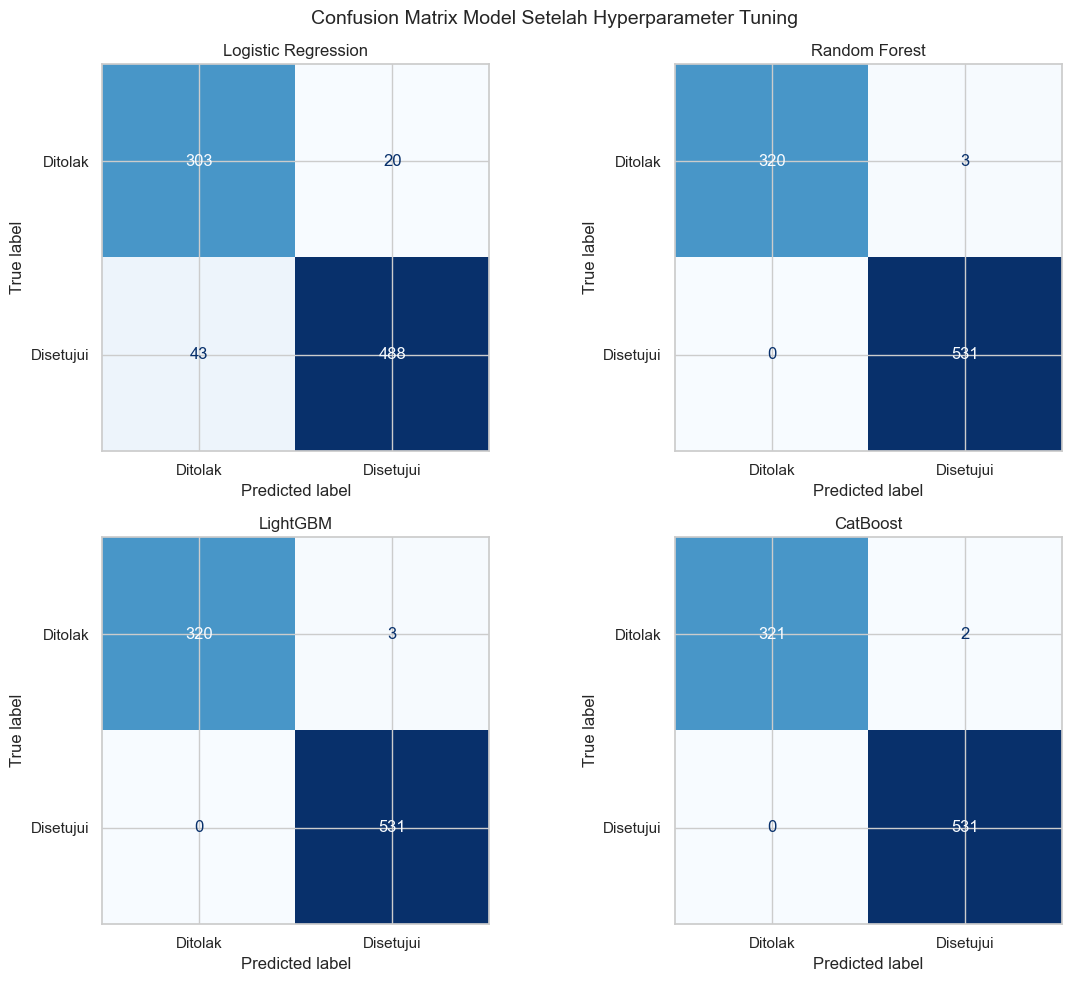

<Figure size 900x700 with 0 Axes>

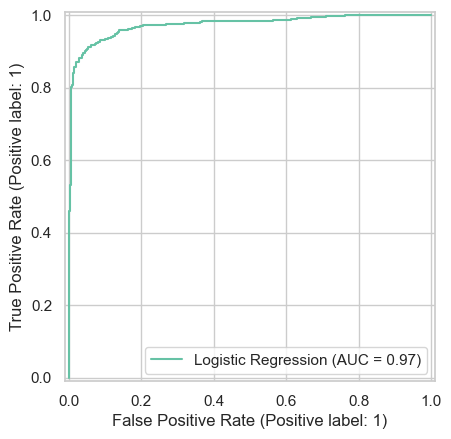

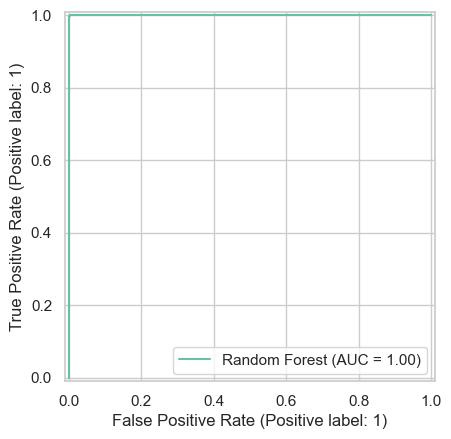

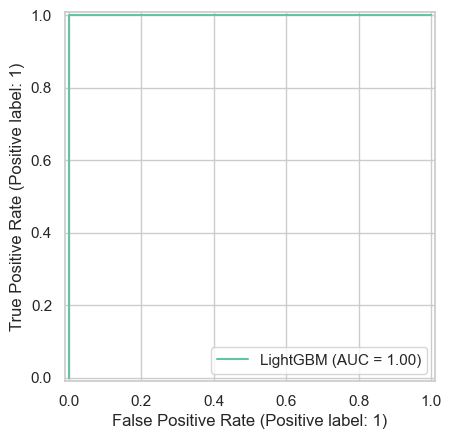

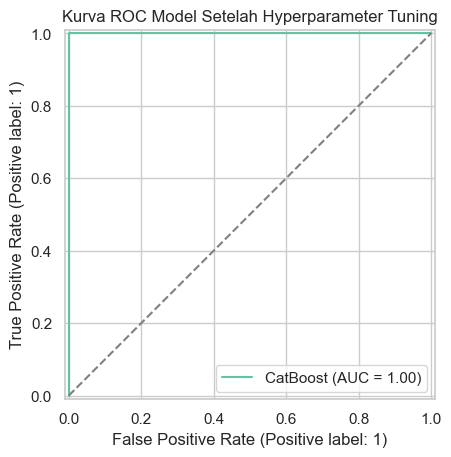

In [13]:
display(ringkasan_validasi_penyetelan.round(4))
display(hasil_akhir_penyetelan_df.round(4))


# ── Tabel Hasil Fine Tuning pada Data Uji (ringkasan bersih) ──
display(Markdown('**Tabel Hasil Hyperparameter Tuning pada Data Uji**'))
tabel_tuning_uji = hasil_akhir_penyetelan_df[[
    'model', 'akurasi_uji', 'presisi_uji', 'recall_uji', 'f1_uji', 'roc_auc_uji'
]].copy()
tabel_tuning_uji.columns = ['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
tabel_tuning_uji = tabel_tuning_uji.reset_index(drop=True)
display(tabel_tuning_uji.round(4))
tampilkan_matriks_kebingungan(
    kumpulan_prediksi=prediksi_uji_penyetelan,
    y_asli=y_uji,
    judul_grafik="Confusion Matrix Model Setelah Hyperparameter Tuning",
)

tampilkan_kurva_roc(
    kumpulan_probabilitas=probabilitas_uji_penyetelan,
    y_asli=y_uji,
    judul_grafik="Kurva ROC Model Setelah Hyperparameter Tuning",
)


## Simpan Model Hasil Tuning


In [14]:
# ══════════════════════════════════════════════════════════════
# Simpan Model Hasil Tuning ke File
# ══════════════════════════════════════════════════════════════
import joblib
from pathlib import Path

# Buat folder penyimpanan
dir_model = Path('models_tuned')
dir_model.mkdir(exist_ok=True)

# ── 3 model sklearn Pipeline (sudah include preprocessor) ──
for nama_model, model in model_akhir_penyetelan.items():
    if nama_model == 'CatBoost':
        continue  # CatBoost ditangani terpisah di bawah
    nama_file = nama_model.lower().replace(' ', '_') + '_tuned.joblib'
    path_file  = dir_model / nama_file
    joblib.dump(model, path_file, compress=3)
    ukuran_kb  = path_file.stat().st_size // 1024
    print(f'✓ {nama_model:22s} → {nama_file}  ({ukuran_kb} KB)')

# ── CatBoost: simpan dalam 2 format ──
model_cb = model_akhir_penyetelan['CatBoost']

# Format joblib (universal, bisa diload dengan joblib)
path_cb_jl = dir_model / 'catboost_tuned.joblib'
joblib.dump(model_cb, path_cb_jl, compress=3)
print(f'✓ {"CatBoost":22s} → catboost_tuned.joblib  ({path_cb_jl.stat().st_size // 1024} KB)')

# Format native CatBoost .cbm (lebih portabel untuk deployment)
path_cb_cbm = dir_model / 'catboost_tuned.cbm'
model_cb.save_model(str(path_cb_cbm))
print(f'✓ {"CatBoost":22s} → catboost_tuned.cbm    ({path_cb_cbm.stat().st_size // 1024} KB)')

# ── Ringkasan ──
print(f'\n📁 Semua model tersimpan di folder: ./{dir_model}/')
print('\nFile yang dihasilkan:')
for f in sorted(dir_model.iterdir()):
    print(f'   {f.name:40s} {f.stat().st_size // 1024:5d} KB')

print('\n' + '─'*60)
print('Cara load dan predict:')
print('  # LR / RF / LightGBM (Pipeline, sudah include preprocessor):')
print('  import joblib')
print('  model = joblib.load("models_tuned/lightgbm_tuned.joblib")')
print('  prediksi = model.predict(X_baru)          # X_baru = DataFrame mentah')
print()
print('  # CatBoost:')
print('  model_cb = joblib.load("models_tuned/catboost_tuned.joblib")')
print('  X_baru_cat = siapkan_data_catboost(X_baru, X_kumpulan_latih)')
print('  prediksi = model_cb.predict(X_baru_cat)')


✓ Logistic Regression    → logistic_regression_tuned.joblib  (2 KB)
✓ Random Forest          → random_forest_tuned.joblib  (636 KB)
✓ LightGBM               → lightgbm_tuned.joblib  (58 KB)
✓ CatBoost               → catboost_tuned.joblib  (37 KB)
✓ CatBoost               → catboost_tuned.cbm    (75 KB)

📁 Semua model tersimpan di folder: ./models_tuned/

File yang dihasilkan:
   catboost_tuned.cbm                          75 KB
   catboost_tuned.joblib                       37 KB
   lightgbm_tuned.joblib                       58 KB
   logistic_regression_tuned.joblib             2 KB
   random_forest_tuned.joblib                 636 KB

────────────────────────────────────────────────────────────
Cara load dan predict:
  # LR / RF / LightGBM (Pipeline, sudah include preprocessor):
  import joblib
  model = joblib.load("models_tuned/lightgbm_tuned.joblib")
  prediksi = model.predict(X_baru)          # X_baru = DataFrame mentah

  # CatBoost:
  model_cb = joblib.load("models_tuned/catbo

## Perbandingan


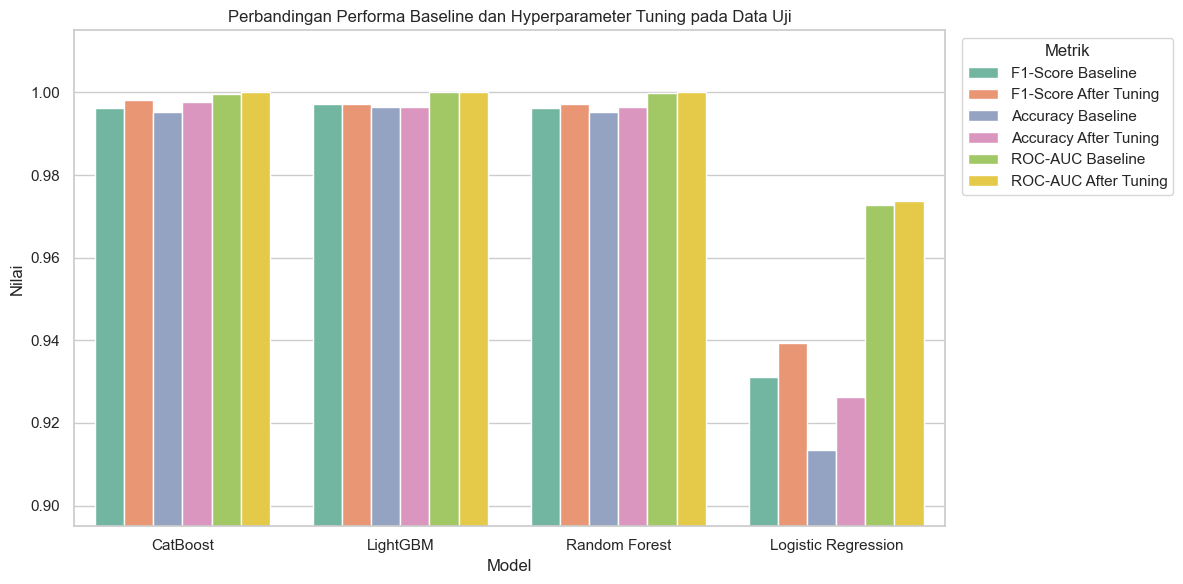

**Tabel Perbandingan Metrik Utama Model Hasil Tuning**

,Model,Acc Baseline,Acc Tuning,F1 Baseline,F1 Tuning,ROC-AUC Baseline,ROC-AUC Tuning
0,CatBoost,0.9953,0.9977,0.9962,0.9981,0.9997,1.0000
1,LightGBM,0.9965,0.9965,0.9972,0.9972,1.0000,1.0000
2,Random Forest,0.9953,0.9965,0.9962,0.9972,0.9999,1.0000
3,Logistic Regression,0.9133,0.9262,0.9312,0.9394,0.9728,0.9738


In [15]:
perbandingan_model_df = (
    hasil_akhir_dasar_df[["model", "akurasi_uji", "f1_uji", "roc_auc_uji"]]
    .merge(
        hasil_akhir_penyetelan_df[["model", "akurasi_uji", "f1_uji", "roc_auc_uji"]],
        on="model",
        suffixes=("_dasar", "_penyetelan"),
    )
    .sort_values("f1_uji_penyetelan", ascending=False)
    .reset_index(drop=True)
)

perbandingan_model_df["delta_akurasi"] = (
    perbandingan_model_df["akurasi_uji_penyetelan"] - perbandingan_model_df["akurasi_uji_dasar"]
)
perbandingan_model_df["delta_f1"] = (
    perbandingan_model_df["f1_uji_penyetelan"] - perbandingan_model_df["f1_uji_dasar"]
)
perbandingan_model_df["delta_roc_auc"] = (
    perbandingan_model_df["roc_auc_uji_penyetelan"] - perbandingan_model_df["roc_auc_uji_dasar"]
)

# ── Bar chart (atas): Baseline vs After Tuning – F1, Accuracy, ROC-AUC ──
data_plot_penyetelan = perbandingan_model_df.melt(
    id_vars=["model"],
    value_vars=[
        "f1_uji_dasar", "f1_uji_penyetelan",
        "akurasi_uji_dasar", "akurasi_uji_penyetelan",
        "roc_auc_uji_dasar", "roc_auc_uji_penyetelan",
    ],
    var_name="jenis_metrik",
    value_name="nilai",
)
data_plot_penyetelan["jenis_metrik"] = data_plot_penyetelan["jenis_metrik"].replace(
    {
        "f1_uji_dasar":             "F1-Score Baseline",
        "f1_uji_penyetelan":        "F1-Score After Tuning",
        "akurasi_uji_dasar":        "Accuracy Baseline",
        "akurasi_uji_penyetelan":   "Accuracy After Tuning",
        "roc_auc_uji_dasar":        "ROC-AUC Baseline",
        "roc_auc_uji_penyetelan":   "ROC-AUC After Tuning",
    }
)

plt.figure(figsize=(12, 6))
sns.barplot(data=data_plot_penyetelan, x="model", y="nilai", hue="jenis_metrik")
plt.ylim(0.895, 1.015)
plt.title("Perbandingan Performa Baseline dan Hyperparameter Tuning pada Data Uji")
plt.xlabel("Model")
plt.ylabel("Nilai")
plt.legend(title="Metrik", bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

# ── Tabel (bawah): Perbandingan Metrik Utama ──
display(Markdown('**Tabel Perbandingan Metrik Utama Model Hasil Tuning**'))
tabel_compare = perbandingan_model_df[[
    "model",
    "akurasi_uji_dasar", "akurasi_uji_penyetelan",
    "f1_uji_dasar",     "f1_uji_penyetelan",
    "roc_auc_uji_dasar", "roc_auc_uji_penyetelan",
]].copy()
tabel_compare.columns = [
    "Model",
    "Acc Baseline", "Acc Tuning",
    "F1 Baseline",  "F1 Tuning",
    "ROC-AUC Baseline", "ROC-AUC Tuning",
]
display(tabel_compare.round(4))


## Rangkuman


In [16]:
model_terbaik_penyetelan = hasil_akhir_penyetelan_df.iloc[0]
model_dengan_gap_terkecil = hasil_akhir_penyetelan_df.sort_values("selisih_latih_uji").iloc[0]

display(
    Markdown(
        f'''
Setelah hyperparameter tuning, model terbaik pada data uji adalah **{model_terbaik_penyetelan["model"]}** dengan **akurasi = {model_terbaik_penyetelan["akurasi_uji"]:.4f}**, **F1-Score = {model_terbaik_penyetelan["f1_uji"]:.4f}**, dan **ROC-AUC = {model_terbaik_penyetelan["roc_auc_uji"]:.4f}**.

Model dengan generalisasi paling stabil berdasarkan gap `latih-uji` adalah **{model_dengan_gap_terkecil["model"]}** dengan gap hanya **{model_dengan_gap_terkecil["selisih_latih_uji"]:.4f}**. Temuan ini memperkuat bahwa tuning tidak hanya diarahkan untuk meningkatkan skor, tetapi juga menjaga kemampuan generalisasi model.
        '''
    )
)



Setelah hyperparameter tuning, model terbaik pada data uji adalah **CatBoost** dengan **akurasi = 0.9977**, **F1-Score = 0.9981**, dan **ROC-AUC = 1.0000**.

Model dengan generalisasi paling stabil berdasarkan gap `latih-uji` adalah **CatBoost** dengan gap hanya **0.0019**. Temuan ini memperkuat bahwa tuning tidak hanya diarahkan untuk meningkatkan skor, tetapi juga menjaga kemampuan generalisasi model.
        

## Kesimpulan


In [17]:
model_akhir_terbaik = hasil_akhir_penyetelan_df.iloc[0]
semua_model_aman = (hasil_akhir_penyetelan_df["status_overfitting_uji"] == "Aman").all()

display(
    Markdown(
        f'''
Berdasarkan keseluruhan eksperimen, algoritma **{model_akhir_terbaik["model"]}** merupakan model paling unggul untuk klasifikasi kelayakan pinjaman pada dataset ini.

Rancangan eksperimen berhasil menjaga validitas model karena:

1. preprocessing tidak menyentuh data uji,
2. hyperparameter tuning hanya dilakukan pada data latih dan validasi,
3. fitur identitas dihapus,
4. gap performa `latih-validasi-uji` relatif kecil.

Status umum pengendalian overfitting pada tahap akhir adalah **{"aman" if semua_model_aman else "perlu pemeriksaan lanjutan"}**.

Dengan demikian, hasil eksperimen dapat digunakan sebagai dasar analisis skripsi dengan tingkat keyakinan metodologis yang lebih baik, terutama terkait isu overfitting dan data leakage.
        '''
    )
)



Berdasarkan keseluruhan eksperimen, algoritma **CatBoost** merupakan model paling unggul untuk klasifikasi kelayakan pinjaman pada dataset ini.

Rancangan eksperimen berhasil menjaga validitas model karena:

1. preprocessing tidak menyentuh data uji,
2. hyperparameter tuning hanya dilakukan pada data latih dan validasi,
3. fitur identitas dihapus,
4. gap performa `latih-validasi-uji` relatif kecil.

Status umum pengendalian overfitting pada tahap akhir adalah **aman**.

Dengan demikian, hasil eksperimen dapat digunakan sebagai dasar analisis skripsi dengan tingkat keyakinan metodologis yang lebih baik, terutama terkait isu overfitting dan data leakage.
        

## Hasil Analisis


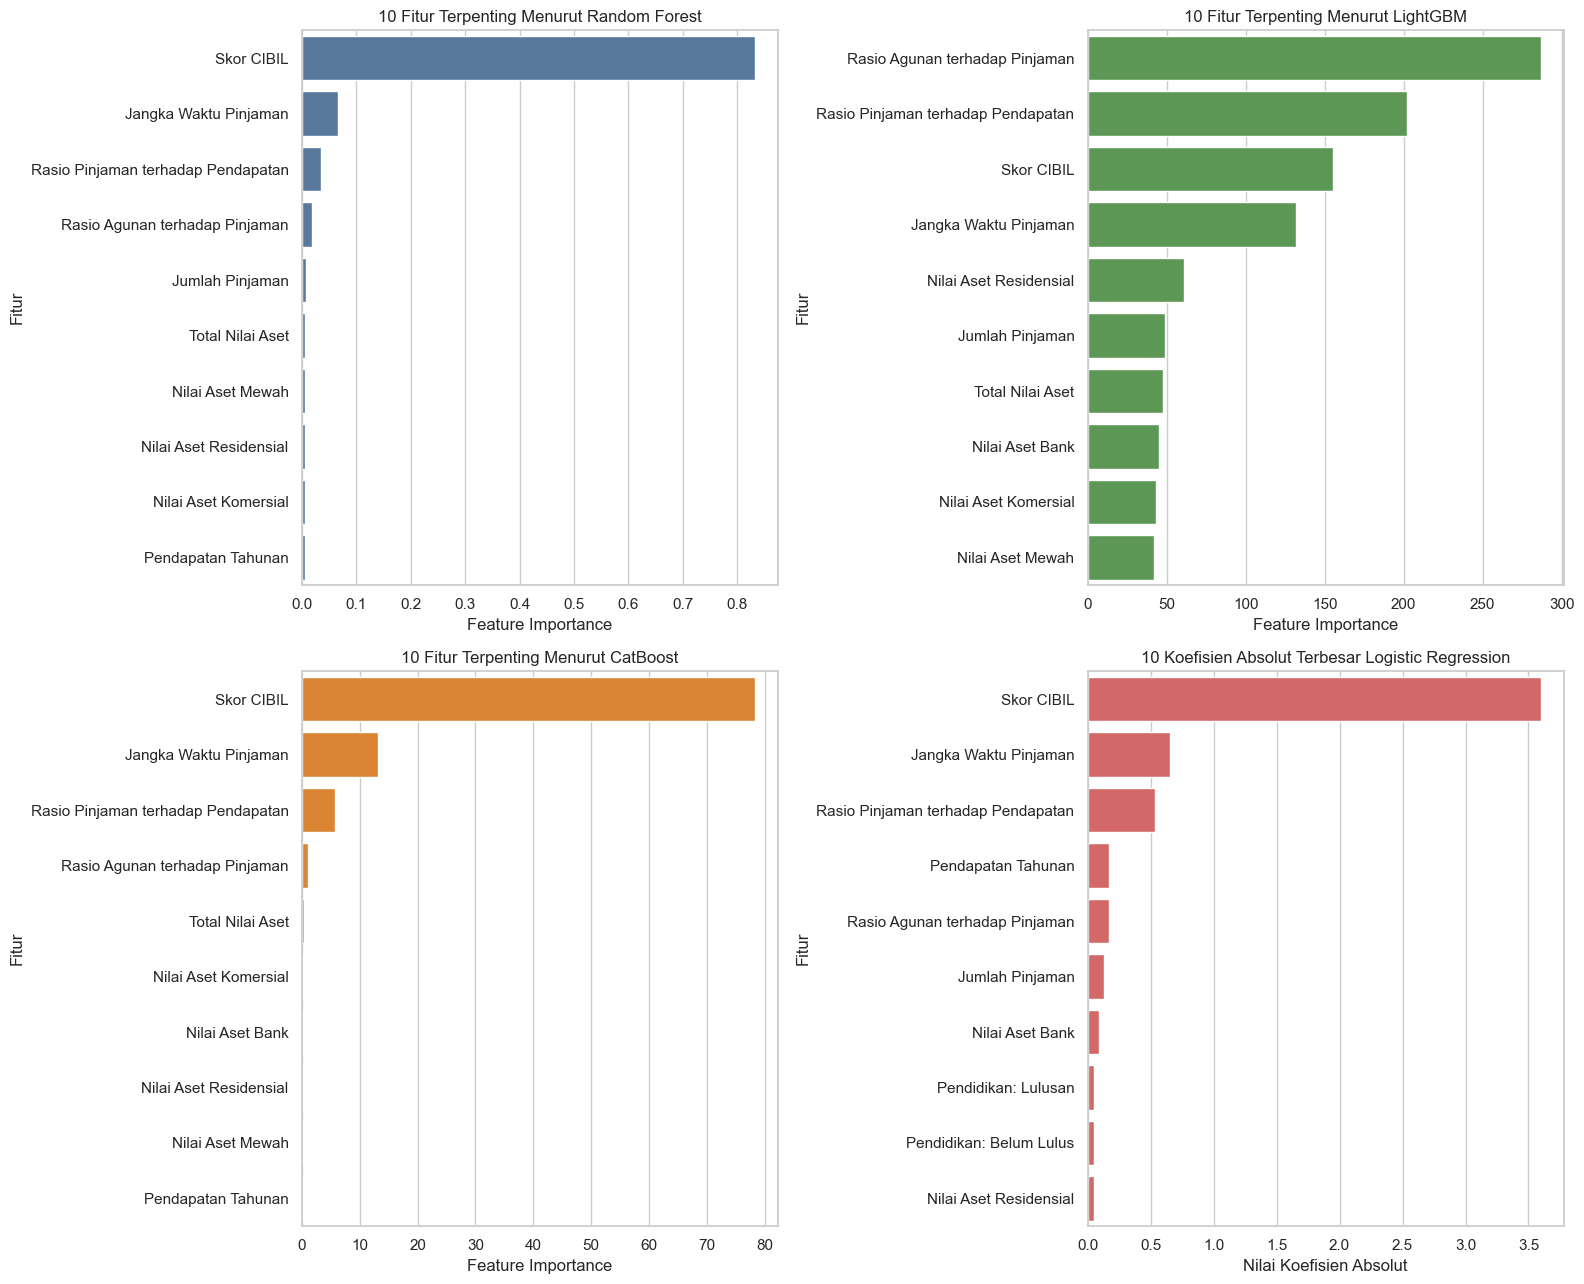


Fitur yang paling konsisten muncul pada model berbasis pohon adalah **Jangka Waktu Pinjaman, Rasio Agunan terhadap Pinjaman, Rasio Pinjaman terhadap Pendapatan, Skor CIBIL**.

Pola ini menguatkan bahwa keputusan persetujuan pinjaman pada dataset sangat dipengaruhi oleh kombinasi **skor CIBIL**, **jumlah pinjaman**, serta **kapasitas aset atau pendapatan**, sehingga akurasi model menjadi sangat tinggi.
        

In [18]:
def rapikan_nama_fitur(daftar_fitur: list[str]) -> list[str]:
    return [
        fitur.replace("numerik__", "").replace("kategori__", "").replace("encoder__", "").replace("ohe__", "")
        for fitur in daftar_fitur
    ]


def terjemahkan_nama_fitur_tampilan(nama_fitur: str) -> str:
    if nama_fitur.startswith("education_"):
        nilai_pendidikan = nama_fitur.replace("education_", "")
        return f'Pendidikan: {peta_pendidikan_tampilan.get(nilai_pendidikan, nilai_pendidikan)}'
    if nama_fitur.startswith("self_employed_"):
        nilai_status = nama_fitur.replace("self_employed_", "")
        return f'Pekerjaan Mandiri: {peta_status_mandiri_tampilan.get(nilai_status, nilai_status)}'
    return peta_nama_kolom_tampilan.get(nama_fitur, nama_fitur.replace("_", " ").title())


model_logistik_akhir = model_akhir_penyetelan["Logistic Regression"]
model_rf_akhir = model_akhir_penyetelan["Random Forest"]
model_lgbm_akhir = model_akhir_penyetelan["LightGBM"]
model_cat_akhir = model_akhir_penyetelan["CatBoost"]

nama_fitur_terenkode = rapikan_nama_fitur(
    list(model_rf_akhir.named_steps["preprosesor"].get_feature_names_out())
)

kepentingan_random_forest = (
    pd.DataFrame(
        {
            "fitur": nama_fitur_terenkode,
            "importance": model_rf_akhir.named_steps["model"].feature_importances_,
        }
    )
    .sort_values("importance", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

kepentingan_lightgbm = (
    pd.DataFrame(
        {
            "fitur": nama_fitur_terenkode,
            "importance": model_lgbm_akhir.named_steps["model"].feature_importances_,
        }
    )
    .sort_values("importance", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

kepentingan_catboost = (
    pd.DataFrame(
        {
            "fitur": X_kumpulan_latih.columns,
            "importance": model_cat_akhir.feature_importances_,
        }
    )
    .sort_values("importance", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

koefisien_logistik = (
    pd.DataFrame(
        {
            "fitur": rapikan_nama_fitur(
                list(model_logistik_akhir.named_steps["preprosesor"].get_feature_names_out())
            ),
            "importance": np.abs(model_logistik_akhir.named_steps["model"].coef_[0]),
        }
    )
    .sort_values("importance", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

for tabel_fitur in [
    kepentingan_random_forest,
    kepentingan_lightgbm,
    kepentingan_catboost,
    koefisien_logistik,
]:
    tabel_fitur["fitur"] = tabel_fitur["fitur"].apply(terjemahkan_nama_fitur_tampilan)

fig, sumbu = plt.subplots(2, 2, figsize=(16, 13))

sns.barplot(data=kepentingan_random_forest, x="importance", y="fitur", ax=sumbu[0, 0], color="#4C78A8")
sumbu[0, 0].set_title("10 Fitur Terpenting Menurut Random Forest")
sumbu[0, 0].set_xlabel("Feature Importance")
sumbu[0, 0].set_ylabel("Fitur")

sns.barplot(data=kepentingan_lightgbm, x="importance", y="fitur", ax=sumbu[0, 1], color="#54A24B")
sumbu[0, 1].set_title("10 Fitur Terpenting Menurut LightGBM")
sumbu[0, 1].set_xlabel("Feature Importance")
sumbu[0, 1].set_ylabel("Fitur")

sns.barplot(data=kepentingan_catboost, x="importance", y="fitur", ax=sumbu[1, 0], color="#F58518")
sumbu[1, 0].set_title("10 Fitur Terpenting Menurut CatBoost")
sumbu[1, 0].set_xlabel("Feature Importance")
sumbu[1, 0].set_ylabel("Fitur")

sns.barplot(data=koefisien_logistik, x="importance", y="fitur", ax=sumbu[1, 1], color="#E45756")
sumbu[1, 1].set_title("10 Koefisien Absolut Terbesar Logistic Regression")
sumbu[1, 1].set_xlabel("Nilai Koefisien Absolut")
sumbu[1, 1].set_ylabel("Fitur")

plt.tight_layout()
plt.show()

fitur_random_forest = set(kepentingan_random_forest["fitur"].head(5))
fitur_lightgbm = set(kepentingan_lightgbm["fitur"].head(5))
fitur_catboost = set(kepentingan_catboost["fitur"].head(5))
fitur_logistik = set(koefisien_logistik["fitur"].head(5))

fitur_konsisten = fitur_random_forest & fitur_lightgbm & fitur_catboost
if not fitur_konsisten:
    fitur_konsisten = fitur_random_forest | fitur_lightgbm | fitur_catboost

display(
    Markdown(
        f'''
Fitur yang paling konsisten muncul pada model berbasis pohon adalah **{", ".join(sorted(fitur_konsisten))}**.

Pola ini menguatkan bahwa keputusan persetujuan pinjaman pada dataset sangat dipengaruhi oleh kombinasi **skor CIBIL**, **jumlah pinjaman**, serta **kapasitas aset atau pendapatan**, sehingga akurasi model menjadi sangat tinggi.
        '''
    )
)
